# Wrist sensor combinations for stress classification

## Research question
How does the combination of wrist sensor inputs affect classification of stress versus baseline and amusement in unseen WESAD participants?

## Approach
Extract summary features from 60-second windows and compare sensor configurations using leave-one-subject-out evaluation across 15 participants.

## Scope
This is an exploratory analysis of laboratory data. It compares predictive performance across sensor inputs; participant burden, battery consumption and clinical usefulness are not measured.

In [3]:
!rm WESAD.zip
!wget -O WESAD.zip "https://uni-siegen.sciebo.de/s/HGdUkoNlW1Ub0Gx/download"

--2026-10-01 19:43:02--  https://uni-siegen.sciebo.de/s/HGdUkoNlW1Ub0Gx/download
Resolving uni-siegen.sciebo.de (uni-siegen.sciebo.de)... 128.176.1.4
Connecting to uni-siegen.sciebo.de (uni-siegen.sciebo.de)|128.176.1.4|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://uni-siegen.sciebo.de/public.php/dav/files/HGdUkoNlW1Ub0Gx [following]
--2026-10-01 19:43:02--  https://uni-siegen.sciebo.de/public.php/dav/files/HGdUkoNlW1Ub0Gx
Reusing existing connection to uni-siegen.sciebo.de:443.
HTTP request sent, awaiting response... 200 OK
Length: 2249444501 (2.1G) [application/zip]
Saving to: ‘WESAD.zip’

WESAD.zip           100%[===================>]   2.09G  37.3MB/s    in 58s     

2026-10-01 19:44:01 (36.8 MB/s) - ‘WESAD.zip’ saved [2249444501/2249444501]



In [4]:
!unzip -q WESAD.zip
!ls

sample_data  WESAD  WESAD.zip


In [5]:
!ls WESAD
!ls WESAD/S2

S10  S13  S15  S17  S3	S5  S7	S9
S11  S14  S16  S2   S4	S6  S8	wesad_readme.pdf
S2_E4_Data.zip	S2.pkl	S2_quest.csv  S2_readme.txt  S2_respiban.txt


In [6]:
import pickle

with open('WESAD/S2/S2.pkl', 'rb') as f:
    data = pickle.load(f, encoding='latin1')

print(data.keys())
print(data['subject'])
print(data['signal'].keys())
print(data['signal']['wrist'].keys())
print(data['signal']['chest'].keys())

dict_keys(['signal', 'label', 'subject'])
S2
dict_keys(['chest', 'wrist'])
dict_keys(['ACC', 'BVP', 'EDA', 'TEMP'])
dict_keys(['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp'])


In [7]:
for name, values in data['signal']['wrist'].items():
    print('wrist', name, values.shape)

for name, values in data['signal']['chest'].items():
    print('chest', name, values.shape)

print('label', data['label'].shape)

wrist ACC (194528, 3)
wrist BVP (389056, 1)
wrist EDA (24316, 1)
wrist TEMP (24316, 1)
chest ACC (4255300, 3)
chest ECG (4255300, 1)
chest EMG (4255300, 1)
chest EDA (4255300, 1)
chest Temp (4255300, 1)
chest Resp (4255300, 1)
label (4255300,)


In [8]:
import numpy as np

labels = data['label']
values, counts = np.unique(labels, return_counts=True)
for v, c in zip(values, counts):
    print(v, c, round(c / 700 / 60, 1), 'minutes')

0 2142701 51.0 minutes
1 800800 19.1 minutes
2 430500 10.2 minutes
3 253400 6.0 minutes
4 537599 12.8 minutes
6 45500 1.1 minutes
7 44800 1.1 minutes


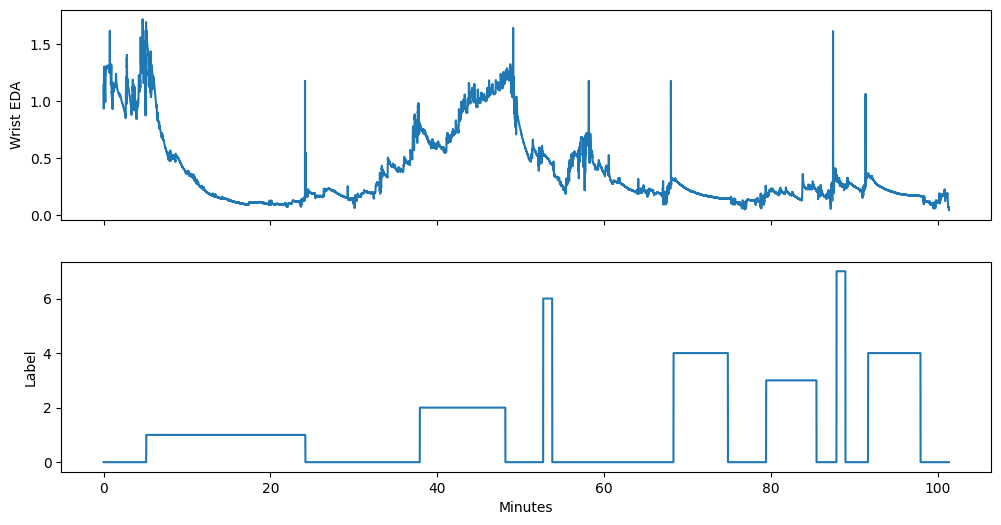

In [9]:
import matplotlib.pyplot as plt

eda = data['signal']['wrist']['EDA'].flatten()
minutes = np.arange(len(eda)) / 4 / 60
labels_4hz = labels[::175][:len(eda)]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(minutes, eda)
axes[0].set_ylabel('Wrist EDA')
axes[1].plot(minutes, labels_4hz)
axes[1].set_ylabel('Label')
axes[1].set_xlabel('Minutes')
plt.show()

In [10]:
import pandas as pd

fs = 4                    # wrist EDA/TEMP: 4 readings per second
win = 60 * fs             # a 60-second window = 240 readings
step = 30 * fs            # slide forward 30 seconds each time

eda = data['signal']['wrist']['EDA'].flatten()
temp = data['signal']['wrist']['TEMP'].flatten()
lab = data['label'][::175][:len(eda)]   # shrink labels to 4 per second

rows = []
for start in range(0, len(eda) - win + 1, step):
    end = start + win
    window_labels = lab[start:end]

    if len(np.unique(window_labels)) != 1:
        continue          # skip windows that straddle two conditions
    label = window_labels[0]
    if label not in (1, 2, 3):
        continue          # keep baseline, stress and amusement only

    e = eda[start:end]
    t = temp[start:end]
    x = np.arange(win)
    rows.append({
        'subject': data['subject'],
        'label': label,
        'stress': int(label == 2),
        'eda_mean': e.mean(), 'eda_std': e.std(),
        'eda_min': e.min(), 'eda_max': e.max(),
        'eda_slope': np.polyfit(x, e, 1)[0],
        'temp_mean': t.mean(), 'temp_std': t.std(),
        'temp_slope': np.polyfit(x, t, 1)[0],
    })

df = pd.DataFrame(rows)
print(df.shape)
print(df['stress'].value_counts())
df.head()

(65, 11)
stress
0    46
1    19
Name: count, dtype: int64


,subject,label,stress,eda_mean,eda_std,eda_min,eda_max,eda_slope,temp_mean,temp_std,temp_slope
0,S2,1,0,1.112433,0.140843,0.831920,1.436807,-0.001629,35.759000,0.051501,-0.000697
1,S2,1,0,0.888839,0.152056,0.679441,1.198480,-0.002144,35.710000,0.026331,-0.000135
2,S2,1,0,0.701357,0.076838,0.570528,0.843452,-0.001097,35.727667,0.032576,0.000391
3,S2,1,0,0.581121,0.068987,0.474428,0.720444,-0.000962,35.784667,0.039894,0.000538
4,S2,1,0,0.513440,0.023343,0.474428,0.569247,-0.000180,35.831833,0.023699,0.000204


In [21]:
import os, pickle
import numpy as np
import pandas as pd

FS = {'EDA': 4, 'TEMP': 4, 'BVP': 64, 'ACC': 32}   # wrist sampling rates (readings per second)
LABEL_FS = 700                                      # labels are recorded at 700 per second
WIN_S, STEP_S = 60, 30                              # 60-second windows, sliding 30 seconds

def build_windows(subject):
    with open(f'WESAD/{subject}/{subject}.pkl', 'rb') as f:
        d = pickle.load(f, encoding='latin1')
    wrist = d['signal']['wrist']
    labels = d['label']
    sig = {
        'EDA':  wrist['EDA'].flatten(),
        'TEMP': wrist['TEMP'].flatten(),
        'BVP':  wrist['BVP'].flatten(),
        'ACC':  np.linalg.norm(wrist['ACC'], axis=1),   # overall movement size
    }
    rows = []
    total_s = len(labels) // LABEL_FS
    for t0 in range(0, total_s - WIN_S + 1, STEP_S):
        t1 = t0 + WIN_S
        w_lab = labels[t0 * LABEL_FS : t1 * LABEL_FS]
        if len(np.unique(w_lab)) != 1:
            continue                      # window spans two conditions
        label = int(w_lab[0])
        if label not in (1, 2, 3):
            continue                      # keep baseline, stress, amusement only
        row = {
    'subject': subject,
    'start_s': t0,
    'end_s': t1,
    'label': label,
    'stress': int(label == 2),
}
        for name, x in sig.items():
            seg = x[t0 * FS[name] : t1 * FS[name]]
            key = name.lower()
            row[f'{key}_mean'] = seg.mean()
            row[f'{key}_std'] = seg.std()
            row[f'{key}_min'] = seg.min()
            row[f'{key}_max'] = seg.max()
            if name in ('EDA', 'TEMP'):
                secs = np.arange(len(seg)) / FS[name]
                row[f'{key}_slope'] = np.polyfit(secs, seg, 1)[0]   # change per second
        rows.append(row)
    return pd.DataFrame(rows)

subjects = sorted(
    [s for s in os.listdir('WESAD') if s.startswith('S') and os.path.isdir(f'WESAD/{s}')],
    key=lambda s: int(s[1:])
)
print(subjects)

frames = []
for s in subjects:
    part = build_windows(s)
    print(s, part.shape)
    frames.append(part)

all_df = pd.concat(frames, ignore_index=True)
print(all_df.shape)
print(all_df.groupby('subject')['stress'].agg(['count', 'sum']))
all_df.to_csv('wesad_wrist_features.csv', index=False)

['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']
S2 (65, 23)
S3 (67, 23)
S4 (66, 23)
S5 (67, 23)
S6 (67, 23)
S7 (67, 23)
S8 (68, 23)
S9 (66, 23)
S10 (69, 23)
S11 (70, 23)
S13 (69, 23)
S14 (69, 23)
S15 (69, 23)
S16 (67, 23)
S17 (69, 23)
(1015, 23)
         count  sum
subject            
S10         69   22
S11         70   21
S13         69   20
S14         69   20
S15         69   21
S16         67   20
S17         69   22
S2          65   19
S3          67   20
S4          66   19
S5          67   19
S6          67   20
S7          67   19
S8          68   21
S9          66   19


In [32]:
import numpy as np
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score, f1_score

metadata_cols = {'subject', 'start_s', 'end_s', 'label', 'stress'}
feature_cols = [c for c in all_df.columns if c not in metadata_cols]
print(len(feature_cols), 'features:', feature_cols)

print('Feature-table shape:', all_df.shape)
print(all_df[['subject', 'start_s', 'end_s']].head())

assert {'start_s', 'end_s'}.issubset(all_df.columns)
assert (all_df['end_s'] - all_df['start_s']).eq(WIN_S).all()
assert not {'start_s', 'end_s', 'subject', 'label', 'stress'} & set(feature_cols)

print('Checks passed: window lengths correct; metadata excluded from predictors.')

models = {
    'Majority-class baseline': lambda: DummyClassifier(strategy='most_frequent'),
    'Logistic regression': lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight='balanced')),
    'Gradient boosting': lambda: HistGradientBoostingClassifier(class_weight='balanced', random_state=0),
}

subjects = sorted(all_df['subject'].unique(), key=lambda s: int(s[1:]))
results = []

for test_subject in subjects:
    train = all_df[all_df['subject'] != test_subject]   # the other 14 people
    test = all_df[all_df['subject'] == test_subject]    # the unseen person
    for model_name, make_model in models.items():
        model = make_model()
        model.fit(train[feature_cols], train['stress'])
        pred = model.predict(test[feature_cols])
        results.append({
            'test_subject': test_subject,
            'model': model_name,
            'balanced_acc': balanced_accuracy_score(test['stress'], pred),
            'f1_stress': f1_score(test['stress'], pred, zero_division=0),
        })

results = pd.DataFrame(results)
summary = results.groupby('model')[['balanced_acc', 'f1_stress']].agg(['mean', 'std']).round(3)
print(summary)
print()
print(results.pivot(index='test_subject', columns='model', values='balanced_acc').round(2))

18 features: ['eda_mean', 'eda_std', 'eda_min', 'eda_max', 'eda_slope', 'temp_mean', 'temp_std', 'temp_min', 'temp_max', 'temp_slope', 'bvp_mean', 'bvp_std', 'bvp_min', 'bvp_max', 'acc_mean', 'acc_std', 'acc_min', 'acc_max']
Feature-table shape: (1015, 23)
  subject  start_s  end_s
0      S2      330    390
1      S2      360    420
2      S2      390    450
3      S2      420    480
4      S2      450    510
Checks passed: window lengths correct; metadata excluded from predictors.
                        balanced_acc        f1_stress       
                                mean    std      mean    std
model                                                       
Gradient boosting              0.786  0.143     0.670  0.282
Logistic regression            0.756  0.146     0.641  0.219
Majority-class baseline        0.500  0.000     0.000  0.000

model         Gradient boosting  Logistic regression  Majority-class baseline
test_subject                                                        

                    mean    std
sensor_set                     
EDA + TEMP         0.801  0.119
All wrist sensors  0.786  0.143
EDA + TEMP + ACC   0.782  0.136
EDA only           0.716  0.120
ACC only           0.687  0.097
TEMP only          0.661  0.226
BVP only           0.558  0.100


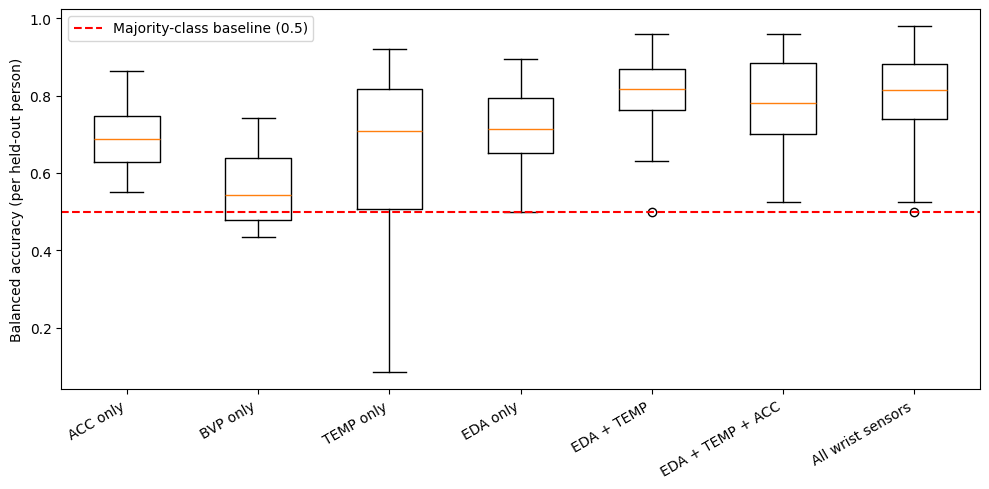

In [24]:
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import balanced_accuracy_score

def cols_for(*prefixes):
    return [c for c in all_df.columns if c.startswith(tuple(p + '_' for p in prefixes))]

sensor_sets = {
    'ACC only': cols_for('acc'),
    'BVP only': cols_for('bvp'),
    'TEMP only': cols_for('temp'),
    'EDA only': cols_for('eda'),
    'EDA + TEMP': cols_for('eda', 'temp'),
    'EDA + TEMP + ACC': cols_for('eda', 'temp', 'acc'),
    'All wrist sensors': cols_for('eda', 'temp', 'acc', 'bvp'),
}

make_model = lambda: HistGradientBoostingClassifier(class_weight='balanced', random_state=0)
subjects = sorted(all_df['subject'].unique(), key=lambda s: int(s[1:]))

rows = []
for set_name, cols in sensor_sets.items():
    for test_subject in subjects:
        train = all_df[all_df['subject'] != test_subject]
        test = all_df[all_df['subject'] == test_subject]
        model = make_model()
        model.fit(train[cols], train['stress'])
        pred = model.predict(test[cols])
        rows.append({'sensor_set': set_name, 'test_subject': test_subject,
                     'balanced_acc': balanced_accuracy_score(test['stress'], pred)})

sensor_results = pd.DataFrame(rows)
print(sensor_results.groupby('sensor_set')['balanced_acc'].agg(['mean', 'std']).round(3).sort_values('mean', ascending=False))

order = list(sensor_sets.keys())
data_to_plot = [sensor_results[sensor_results['sensor_set'] == s]['balanced_acc'] for s in order]
plt.figure(figsize=(10, 5))
plt.boxplot(data_to_plot)
plt.xticks(range(1, len(order) + 1), order, rotation=30, ha='right')
plt.axhline(0.5, color='red', linestyle='--', label='Majority-class baseline (0.5)')
plt.ylabel('Balanced accuracy (per held-out person)')
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, f1_score
import os

cols = sensor_sets['EDA + TEMP']
participant_rows = []
prediction_frames = []

for subject in subjects:
    train = all_df[all_df['subject'] != subject]
    test = all_df[all_df['subject'] == subject].copy()

    model = make_model()
    model.fit(train[cols], train['stress'])
    pred = model.predict(test[cols])

    tn, fp, fn, tp = confusion_matrix(
        test['stress'], pred, labels=[0, 1]
    ).ravel()

    participant_rows.append({
        'subject': subject,
        'balanced_acc': balanced_accuracy_score(test['stress'], pred),
        'stress_sensitivity': tp / (tp + fn),
        'specificity': tn / (tn + fp),
        'f1_stress': f1_score(test['stress'], pred, zero_division=0),
        'true_negatives': tn,
        'false_positives': fp,
        'false_negatives': fn,
        'true_positives': tp,
    })

    window_predictions = test[
        ['subject', 'start_s', 'end_s', 'label', 'stress']
    ].copy()
    window_predictions['predicted_stress'] = pred
    prediction_frames.append(window_predictions)

participant_metrics = pd.DataFrame(participant_rows)
window_predictions = pd.concat(prediction_frames, ignore_index=True)

os.makedirs('results', exist_ok=True)
participant_metrics.to_csv(
    'results/eda_temp_participant_metrics.csv', index=False
)
window_predictions.to_csv(
    'results/eda_temp_window_predictions.csv', index=False
)

print(participant_metrics.round(3).to_string(index=False))
print('\nMean across participants:')
print(participant_metrics[
    ['balanced_acc', 'stress_sensitivity', 'specificity', 'f1_stress']
].mean().round(3))

subject  balanced_acc  stress_sensitivity  specificity  f1_stress  true_negatives  false_positives  false_negatives  true_positives
     S2         0.789               0.579        1.000      0.733              46                0                8              11
     S3         0.759               0.900        0.617      0.643              29               18                2              18
     S4         0.921               0.842        1.000      0.914              47                0                3              16
     S5         0.789               0.579        1.000      0.733              48                0                8              11
     S6         0.840               1.000        0.681      0.727              32               15                0              20
     S7         0.765               0.947        0.583      0.632              28               20                1              18
     S8         0.738               0.476        1.000      0.645           

## Participant-level performance

The EDA + temperature model achieved mean participant-level balanced
accuracy of 0.801, stress sensitivity of 0.742, specificity of 0.860,
and stress-class F1 of 0.703.

Performance varied substantially between participants. The model missed
all 20 stress windows for S14. For S8, it detected 10 of 21 stress windows
without producing false positives. For S17, it detected 17 of 22 stress
windows but incorrectly classified 24 of 47 non-stress windows as stress.

These results show that average balanced accuracy can conceal different
failure patterns, including missed stress and frequent false alarms.
Sensitivity and specificity should therefore be reported alongside
balanced accuracy. Windows overlap, so these counts do not represent
independent stress events.

In [34]:
# Follow-up robustness check: 60-second windows, 60-second step.
# Keep the original all_df and sensor_results unchanged.

nonoverlap_df = all_df[
    all_df['start_s'] % WIN_S == 0
].copy()

# Check that retained windows do not overlap within each participant.
for subject, part in nonoverlap_df.groupby('subject'):
    part = part.sort_values('start_s')
    assert (
        part['start_s'].to_numpy()[1:]
        >= part['end_s'].to_numpy()[:-1]
    ).all()

print('Non-overlapping windows:', len(nonoverlap_df))
print(nonoverlap_df.groupby('subject')['stress'].agg(['count', 'sum']))

robustness_rows = []

for set_name, cols in sensor_sets.items():
    for subject in subjects:
        train = nonoverlap_df[nonoverlap_df['subject'] != subject]
        test = nonoverlap_df[nonoverlap_df['subject'] == subject]

        assert set(test['stress']) == {0, 1}

        model = make_model()
        model.fit(train[cols], train['stress'])
        pred = model.predict(test[cols])

        robustness_rows.append({
            'sensor_set': set_name,
            'test_subject': subject,
            'balanced_acc': balanced_accuracy_score(test['stress'], pred),
        })

nonoverlap_results = pd.DataFrame(robustness_rows)

comparison = pd.concat({
    '30-second step': sensor_results.groupby('sensor_set')['balanced_acc'].mean(),
    '60-second step': nonoverlap_results.groupby('sensor_set')['balanced_acc'].mean(),
}, axis=1)

comparison['difference'] = (
    comparison['60-second step'] - comparison['30-second step']
)

os.makedirs('results', exist_ok=True)
nonoverlap_results.to_csv(
    'results/nonoverlap_sensor_results.csv', index=False
)
comparison.to_csv('results/window_overlap_comparison.csv')

print('\nMean balanced accuracy across participants:')
print(comparison.round(3).to_string())

Non-overlapping windows: 513
         count  sum
subject            
S10         35   11
S11         35   11
S13         35   10
S14         35   10
S15         36   11
S16         34   10
S17         35   11
S2          33   10
S3          33   10
S4          33    9
S5          33    9
S6          34   10
S7          35   10
S8          35   11
S9          32    9

Mean balanced accuracy across participants:
                   30-second step  60-second step  difference
sensor_set                                                   
ACC only                    0.687           0.686      -0.001
All wrist sensors           0.786           0.823       0.038
BVP only                    0.558           0.521      -0.037
EDA + TEMP                  0.801           0.823       0.022
EDA + TEMP + ACC            0.782           0.824       0.042
EDA only                    0.716           0.713      -0.003
TEMP only                   0.661           0.690       0.029


## Robustness check: non-overlapping windows

Repeating the sensor comparison using 60-second windows with a
60-second step retained 513 windows across 15 participants.

Mean balanced accuracy was 0.823 for EDA + temperature, 0.823 for
all wrist sensors, and 0.824 for EDA + temperature + acceleration.
EDA alone achieved 0.713.

EDA + temperature remained competitive with the larger sensor
configurations, although the exact ranking changed. These results
support similar observed average performance for these configurations;
they do not establish statistical equivalence or show that additional
sensors are unnecessary.

This check changes both the training sample and the evaluated windows,
so score differences cannot be attributed solely to removing overlap.
Adjacent non-overlapping windows may still be temporally correlated.

In [25]:
from scipy.stats import wilcoxon

wide = sensor_results.pivot(index='test_subject', columns='sensor_set', values='balanced_acc')
print(wide[['EDA only', 'EDA + TEMP', 'EDA + TEMP + ACC', 'All wrist sensors']].round(2))

def paired(a, b):
    diff = wide[a] - wide[b]
    stat, p = wilcoxon(diff)
    print(f'{a} vs {b}: mean diff {diff.mean():+.3f}, people better with {a}: {(diff > 0).sum()}/{len(diff)}, p = {p:.3f}')

paired('EDA + TEMP', 'EDA only')
paired('EDA + TEMP', 'All wrist sensors')
paired('EDA + TEMP', 'EDA + TEMP + ACC')

sensor_set    EDA only  EDA + TEMP  EDA + TEMP + ACC  All wrist sensors
test_subject                                                           
S10               0.77        0.82              0.86               0.86
S11               0.66        0.84              0.84               0.82
S13               0.71        0.96              0.95               0.98
S14               0.50        0.50              0.52               0.50
S15               0.71        0.94              0.96               0.91
S16               0.80        0.82              0.55               0.52
S17               0.70        0.63              0.64               0.61
S2                0.83        0.79              0.78               0.82
S3                0.65        0.76              0.72               0.81
S4                0.87        0.92              0.92               0.89
S5                0.53        0.79              0.68               0.74
S6                0.79        0.84              0.77            

In [26]:
cols = sensor_sets['EDA + TEMP']
train = all_df[all_df['subject'] != 'S14']
test = all_df[all_df['subject'] == 'S14']
model = make_model().fit(train[cols], train['stress'])
print(pd.crosstab(test['stress'], model.predict(test[cols]),
                  rownames=['true stress'], colnames=['predicted']))

predicted     0
true stress    
0            49
1            20


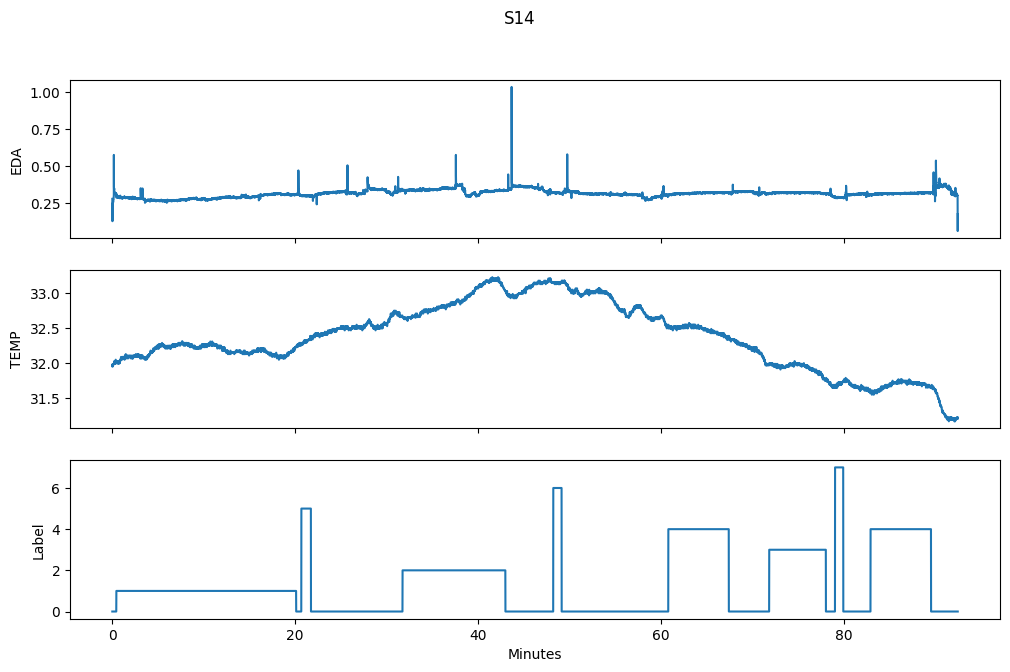

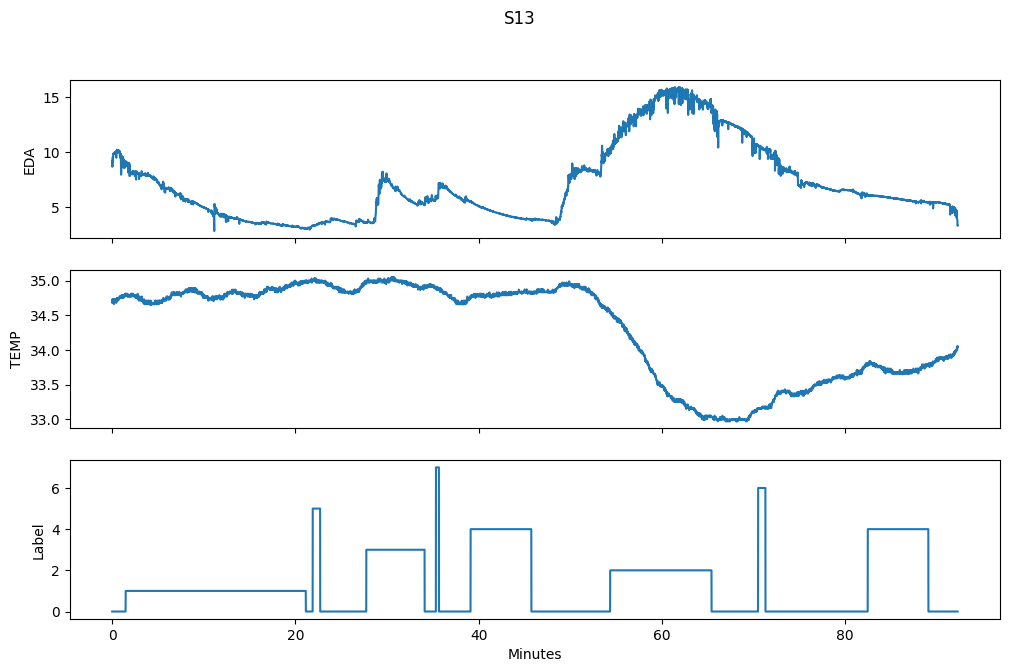

In [27]:
import matplotlib.pyplot as plt

def plot_subject(subject):
    with open(f'WESAD/{subject}/{subject}.pkl', 'rb') as f:
        d = pickle.load(f, encoding='latin1')
    eda = d['signal']['wrist']['EDA'].flatten()
    temp = d['signal']['wrist']['TEMP'].flatten()
    lab = d['label'][::175][:len(eda)]
    minutes = np.arange(len(eda)) / 4 / 60
    fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
    axes[0].plot(minutes, eda); axes[0].set_ylabel('EDA')
    axes[1].plot(minutes, temp); axes[1].set_ylabel('TEMP')
    axes[2].plot(minutes, lab); axes[2].set_ylabel('Label'); axes[2].set_xlabel('Minutes')
    fig.suptitle(subject)
    plt.show()

plot_subject('S14')
plot_subject('S13')

In [35]:
from scipy.stats import wilcoxon

cols = sensor_sets['EDA + TEMP']
subjects = sorted(all_df['subject'].unique(), key=lambda s: int(s[1:]))
CALIB = 19   # first 19 baseline windows (about the first 10 minutes) = calibration period

norm_df = all_df.copy()
norm_df['skip'] = False
for subj in subjects:
    mask = all_df['subject'] == subj
    base_idx = all_df[mask & (all_df['label'] == 1)].index     # chronological order
    calib = all_df.loc[base_idx[:CALIB], cols]
    mu = calib.mean()
    sd = calib.std().replace(0, np.nan).fillna(1.0)
    norm_df.loc[mask, cols] = (all_df.loc[mask, cols] - mu) / sd
    norm_df.loc[base_idx[:CALIB + 1], 'skip'] = True            # never score calibration windows

raw_df = all_df.copy()
raw_df['skip'] = norm_df['skip']

def loso(df, cols):
    scores = {}
    for test_subject in subjects:
        train = df[df['subject'] != test_subject]
        test = df[(df['subject'] == test_subject) & (~df['skip'])]
        model = make_model().fit(train[cols], train['stress'])
        scores[test_subject] = balanced_accuracy_score(test['stress'], model.predict(test[cols]))
    return pd.Series(scores)

raw_scores = loso(raw_df, cols)
norm_scores = loso(norm_df, cols)

compare = pd.DataFrame({
    'raw': raw_scores,
    'baseline-normalised': norm_scores,
})
print(compare.round(3))
print(compare.mean().round(3))
diff = norm_scores - raw_scores
print(f'mean diff {diff.mean():+.3f}, people better when normalised: {(diff > 0).sum()}/{len(diff)}, p = {wilcoxon(diff)[1]:.3f}')

       raw  baseline-normalised
S2   0.789                0.788
S3   0.839                0.500
S4   0.921                0.870
S5   0.789                1.000
S6   0.815                1.000
S7   0.742                0.816
S8   0.738                1.000
S9   0.895                0.981
S10  0.818                1.000
S11  0.787                0.571
S13  0.983                1.000
S14  0.500                0.379
S15  0.893                0.696
S16  0.825                0.963
S17  0.497                0.645
raw                    0.789
baseline-normalised    0.814
dtype: float64
mean diff +0.025, people better when normalised: 9/15, p = 0.561


## Exploratory baseline calibration

Features were normalised using each participant’s first 19 baseline
windows, covering approximately 10 minutes. Calibration windows and
the next overlapping window were excluded from evaluation. Raw and
normalised models were evaluated on the same remaining windows.

Mean participant-level balanced accuracy increased from 0.789 to
0.814. Normalisation improved scores for 9 of 15 participants, but
the exploratory paired Wilcoxon test provided no clear evidence of
an overall improvement (p = 0.561).

Effects varied between participants, with substantial improvements
and deteriorations. These results do not establish a consistent
benefit from baseline calibration.

In [38]:
import os
os.makedirs('figures', exist_ok=True)
os.makedirs('results', exist_ok=True)

# 1) Sensor-set box plot
order = list(sensor_sets.keys())
data_to_plot = [sensor_results[sensor_results['sensor_set'] == s]['balanced_acc'] for s in order]
plt.figure(figsize=(10, 5))
plt.boxplot(data_to_plot)
plt.xticks(range(1, len(order) + 1), order, rotation=30, ha='right')
plt.axhline(0.5, color='red', linestyle='--', label='Majority-class baseline (0.5)')
plt.ylabel('Balanced accuracy (per held-out person)')
plt.legend()
plt.tight_layout()
plt.savefig('figures/sensor_sets_boxplot.png', dpi=200)
plt.close()

# 2) S13 vs S14 signal plots
def plot_subject(subject):
    with open(f'WESAD/{subject}/{subject}.pkl', 'rb') as f:
        d = pickle.load(f, encoding='latin1')
    eda = d['signal']['wrist']['EDA'].flatten()
    temp = d['signal']['wrist']['TEMP'].flatten()
    lab = d['label'][::175][:len(eda)]
    minutes = np.arange(len(eda)) / 4 / 60
    fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
    axes[0].plot(minutes, eda); axes[0].set_ylabel('EDA')
    axes[1].plot(minutes, temp); axes[1].set_ylabel('TEMP')
    axes[2].plot(minutes, lab); axes[2].set_ylabel('Label'); axes[2].set_xlabel('Minutes')
    fig.suptitle(subject)
    fig.savefig(f'figures/signals_{subject}.png', dpi=200)
    plt.close(fig)

plot_subject('S13')
plot_subject('S14')

# 3) Result tables
all_df.to_csv('results/wesad_wrist_features.csv', index=False)
sensor_results.to_csv('results/sensor_set_results.csv', index=False)
compare.to_csv('results/calibration_comparison.csv')

results.to_csv('results/model_comparison.csv', index=False)

import sys
import sklearn
import scipy
import matplotlib

versions = {
    'python': sys.version.split()[0],
    'numpy': np.__version__,
    'pandas': pd.__version__,
    'scikit-learn': sklearn.__version__,
    'scipy': scipy.__version__,
    'matplotlib': matplotlib.__version__,
}

pd.Series(versions, name='version').to_csv(
    'results/package_versions.csv', index_label='package'
)

In [39]:
!zip -r wesad_outputs.zip figures results
from google.colab import files
files.download('wesad_outputs.zip')

updating: figures/ (stored 0%)
updating: figures/sensor_sets_boxplot.png (deflated 17%)
updating: figures/signals_S13.png (deflated 12%)
updating: figures/signals_S14.png (deflated 14%)
updating: results/ (stored 0%)
updating: results/calibration_comparison.csv (deflated 58%)
updating: results/sensor_set_results.csv (deflated 71%)
updating: results/wesad_wrist_features.csv (deflated 58%)
updating: results/eda_temp_participant_metrics.csv (deflated 60%)
updating: results/eda_temp_window_predictions.csv (deflated 82%)
updating: results/nonoverlap_sensor_results.csv (deflated 77%)
updating: results/window_overlap_comparison.csv (deflated 41%)
  adding: results/package_versions.csv (deflated 15%)
  adding: results/model_comparison.csv (deflated 73%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>